# Phase4: Multi-Factor Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import json
from itertools import combinations
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

In [3]:
import analytics

In [4]:
import operators_library

## 4.1 Data Fetching and Cleaning

## 4.1.1 Data Reader

In [5]:
factors_root = Path("data/Factors")
bundle_dir = max([p for p in factors_root.iterdir() if p.is_dir()], key=lambda p: p.name)

factors_dir = bundle_dir / "factors"
results_dir = bundle_dir / "results"

print(f"Using bundle: {bundle_dir}")

# Parse names
fac_pat = re.compile(r"^fac_(.+)\.parquet$")
res_pat = re.compile(r"^res_(.+)_(coverage|ic_summary|spread_summary)\.parquet$")

factor_pool = {}
coverage = {}
ic_summary = {}
spread_summary = {}

# 1) factor_pool dictionary
for fp in sorted(factors_dir.glob("fac_*.parquet")):
    m = fac_pat.match(fp.name)
    if not m:
        continue
    key = m.group(1)  # e.g. "mr_1"
    df = pd.read_parquet(fp)
    if isinstance(df.index, pd.DatetimeIndex):
        df = df.sort_index()
    factor_pool[key] = df

# 2) result dictionaries
for rp in sorted(results_dir.glob("res_*.parquet")):
    m = res_pat.match(rp.name)
    if not m:
        continue
    key, kind = m.group(1), m.group(2)
    df = pd.read_parquet(rp)

    if kind == "coverage":
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.sort_index()
        coverage[key] = df
    elif kind == "ic_summary":
        ic_summary[key] = df
    elif kind == "spread_summary":
        spread_summary[key] = df

print(f"#factor_pool      : {len(factor_pool)}")
print(f"#coverage         : {len(coverage)}")
print(f"#ic_summary       : {len(ic_summary)}")
print(f"#spread_summary   : {len(spread_summary)}")


Using bundle: data/Factors/20260305_172042
#factor_pool      : 29
#coverage         : 29
#ic_summary       : 29
#spread_summary   : 29


In [6]:
close_path = Path("data/cache/processed_fast/close.parquet")
close_df = pd.read_parquet(close_path).sort_index()
close_df.index = pd.to_datetime(close_df.index)

## 4.1.2 Pre-Processing

In [7]:
# Normalize each alpha: columns, datetime index, numeric
for k in list(factor_pool.keys()):
    df = factor_pool[k]
    df = analytics.simplify_columns(df)
    df = analytics.ensure_datetime_index(df)
    df = analytics.to_numeric(df)
    factor_pool[k] = df

In [8]:
# Define master calendar + ticker set 
px_close = analytics.simplify_columns(analytics.ensure_datetime_index(analytics.to_numeric(close_df)))

tickers_common = set(px_close.columns)
for k, df in factor_pool.items():
    tickers_common &= set(df.columns)

tickers_common = sorted(tickers_common)
print(f"Common tickers across prices + all alphas: {len(tickers_common)}")
master_index = px_close.index  # use price calendar as source of truth

# align all alphas to master index + common tickers
alpha_aligned = {}
for k, df in factor_pool.items():
    alpha_aligned[k] = df.reindex(index=master_index, columns=tickers_common)

px_close = px_close.reindex(index=master_index, columns=tickers_common)

# tradable universe mask (minimum): we can only trade names with a close price
univ = px_close.notna()

Common tickers across prices + all alphas: 1771


In [9]:
# Coverage report
def build_coverage_report(
    factor_pool,
    univ,
    coverage_dict
):
    rows = []
    for fac, df in factor_pool.items():
        m = df.notna()

        # basic coverage stats
        names_per_day = m.sum(axis=1)
        nonnull_days = int((names_per_day > 0).sum())
        start_nonnull = names_per_day[names_per_day > 0].index.min()
        end_nonnull = names_per_day[names_per_day > 0].index.max()

        # numerator: available cells
        avail_cells = float(m.to_numpy().sum())

        # denominator: either universe cells or full panel size
        u = univ.reindex(index=df.index, columns=df.columns).fillna(False).astype(bool)
        valid = m & u                      # only count availability inside universe
        avail_cells = float(valid.to_numpy().sum())
        denom_cells = float(u.to_numpy().sum())
        frac = (avail_cells / denom_cells) if denom_cells > 0 else np.nan

        # optional consistency check with saved coverage series
        cov_mean = np.nan
        if coverage_dict is not None and fac in coverage_dict:
            c = coverage_dict[fac]
            col = "coverage" if "coverage" in c.columns else c.columns[0]
            cov_mean = float(c[col].mean())

        rows.append({
            "factor": fac,
            "start_date_nonnull": pd.NaT if pd.isna(start_nonnull) else pd.Timestamp(start_nonnull),
            "end_date_nonnull": pd.NaT if pd.isna(end_nonnull) else pd.Timestamp(end_nonnull),
            "nonnull_days": nonnull_days,
            "median_names_per_day": float(names_per_day.median()),
            "mean_names_per_day": float(names_per_day.mean()),
            "overall_coverage_frac": float(frac),
            "avg_coverage_series": cov_mean,
        })

    out = pd.DataFrame(rows).sort_values(
        ["overall_coverage_frac", "median_names_per_day"],
        ascending=[False, False]
    ).reset_index(drop=True)
    return out

coverage_report = build_coverage_report(factor_pool, univ, coverage)
display(coverage_report)


,factor,start_date_nonnull,end_date_nonnull,nonnull_days,median_names_per_day,mean_names_per_day,overall_coverage_frac,avg_coverage_series
0,gr_1,1991-01-02,2026-03-02,8583,1771.0,1769.144902,1.000000,1769.144902
1,gr_2,1990-12-19,2026-03-02,8592,1771.0,1771.000000,1.000000,1771.000000
2,mom_2,1990-12-19,2026-03-02,8592,1771.0,1771.000000,1.000000,1771.000000
3,mr_10,1990-12-19,2026-03-02,8592,1771.0,1771.000000,1.000000,1771.000000
4,mr_2,1991-05-27,2026-03-02,8483,1771.0,1748.532705,1.000000,1748.532705
5,va_4,1990-12-19,2026-03-02,8592,1771.0,1771.000000,1.000000,1771.000000
6,mr_8,2007-01-04,2026-03-02,4653,464.0,262.749069,1.000000,262.749069
7,mr_6,1990-12-19,2026-03-02,8592,1771.0,1770.568785,0.999394,1770.568785
8,st_4,2007-01-05,2026-02-27,4651,461.0,262.039455,0.997299,262.039455
9,va_7,1990-12-19,2026-03-02,8592,1769.0,1766.084497,0.991349,1766.084497


## Data Quality Filter (min_overall_coverage>=0.5, min_median_names=300)

In [10]:
def select_factors_data_quality(
    coverage_report,
    min_overall_coverage=0.5,
    min_median_names=300,
    name_col="factor",  # change to "alpha" if your report uses that
):
    m = (
        (coverage_report["overall_coverage_frac"] > min_overall_coverage)
        & (coverage_report["median_names_per_day"] > min_median_names)
    )
    selected = coverage_report.loc[m, name_col].tolist()
    return selected

# usage
selected_factors_dq = select_factors_data_quality(
    coverage_report,
    min_overall_coverage=0.5,
    min_median_names=300,
    name_col="factor",  # or "alpha"
)

print(f"Selected {len(selected_factors_dq)} factors")
print(selected_factors_dq)


Selected 16 factors
['gr_1', 'gr_2', 'mom_2', 'mr_10', 'mr_2', 'va_4', 'mr_8', 'mr_6', 'st_4', 'va_7', 'vo_3', 'mr_1', 'mom_1', 'mom_3', 'mom_5', 'gr_3']


# Mask Continuity

In [11]:
# Define common-sample date mask for the already filtered factors

date_sets = []
for f in selected_factors_dq:
    s = coverage[f]["coverage"]
    d = set(s.index[s > 0])
    date_sets.append(d)

common_dates = sorted(set.intersection(*date_sets))

base_index = close_df.index
mask_common = pd.Series(base_index.isin(common_dates), index=base_index, name="mask_common")

print(mask_common.sum(), "common dates")
display(mask_common.tail())


4391 common dates


Date
2026-02-24     True
2026-02-25     True
2026-02-26     True
2026-02-27     True
2026-03-02    False
Name: mask_common, dtype: bool

In [12]:
s = mask_common.astype(bool).copy()
s.index = pd.to_datetime(s.index)
s = s.sort_index()

# Identify contiguous runs of equal value
run_id = s.ne(s.shift(fill_value=False)).cumsum()

runs = (
    pd.DataFrame({"date": s.index, "is_common": s.values, "run": run_id.values})
    .groupby(["run", "is_common"], as_index=False)
    .agg(start=("date", "first"), end=("date", "last"), n_days=("date", "size"))
)

true_runs = runs[runs["is_common"]].sort_values("n_days", ascending=False).reset_index(drop=True)

print(f"Total common days: {int(s.sum())} / {len(s)} ({s.mean():.2%})")
print(f"# of True segments: {len(true_runs)}")
display(true_runs.head(10))

Total common days: 4391 / 8592 (51.11%)
# of True segments: 1


,run,is_common,start,end,n_days
0,1,True,2008-01-29,2026-02-27,4391


## 4.1.3 Analysis Panels

In [13]:
# Analysis panels

def build_analysis_panels(
    factor_pool: dict[str, pd.DataFrame],
    selected_factors: list[str],
    mask_common: pd.Series,
    univ: pd.DataFrame | None = None,
    min_factors_frac: float = 0.7,
):
    # 1) common date index
    dates = pd.to_datetime(mask_common.index[mask_common.astype(bool)])
    dates = dates.sort_values()

    # 2) common asset set (intersection across selected factors)
    asset_sets = [set(factor_pool[f].columns) for f in selected_factors]
    common_assets = sorted(set.intersection(*asset_sets))
    assets = pd.Index(common_assets, name="asset")

    # 3) align each factor panel to common date/asset universe
    alpha_aligned = {}
    alpha_rank = {}
    for f in selected_factors:
        x = factor_pool[f].reindex(index=dates, columns=assets)
        u = (
            univ.reindex(index=dates, columns=assets)
            .fillna(False)
            .astype(bool)
        )
        x = x.where(u)

        alpha_aligned[f] = x
        alpha_rank[f] = operators_library.rank(x)

    # 4) stack to (date, asset) x factor panels
    panel_raw = pd.concat({f: alpha_aligned[f].stack(dropna=False) for f in selected_factors}, axis=1)
    panel_raw.index.names = ["date", "asset"]
    panel_raw.columns.name = "factor"

    panel_rank = pd.concat({f: alpha_rank[f].stack(dropna=False) for f in selected_factors}, axis=1)
    panel_rank.index.names = ["date", "asset"]
    panel_rank.columns.name = "factor"

    # 5) k_min_factors is the minimum number of non-missing factor values required for a (date, asset) row to be kept in analysis.
    avail_counts = panel_rank.notna().sum(axis=1)
    k_min_factors = max(5, int(np.ceil(min_factors_frac * len(selected_factors))))
    valid_rows = avail_counts >= k_min_factors

    return {
        "dates": dates,
        "assets": assets,
        "alpha_aligned": alpha_aligned,   
        "alpha_rank": alpha_rank,         
        "panel_raw": panel_raw,           # (date, asset) x factor
        "panel_rank": panel_rank,        
        "valid_rows": valid_rows,       
        "k_min_factors": k_min_factors,
    }

panels = build_analysis_panels(
    factor_pool=factor_pool,
    selected_factors=selected_factors_dq,
    mask_common=mask_common,
    univ=univ,
    min_factors_frac=0.7,
)

print("dates:", len(panels["dates"]))
print("assets:", len(panels["assets"]))
print("factors:", len(selected_factors_dq))
print("k_min_factors:", panels["k_min_factors"])
print("panel_rank shape:", panels["panel_rank"].shape)
print("valid rows:", int(panels["valid_rows"].sum()))
display(panels["panel_rank"].head())


/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/3853633881.py:35: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  panel_raw = pd.concat({f: alpha_aligned[f].stack(dropna=False) for f in selected_factors}, axis=1)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/3853633881.py:35: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  panel_raw = pd.concat({f: alpha_aligned[f].stack(dropna=False) for f in selected_factors}, axis=1)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/3853633881.py:35: FutureWarning: The previous implement

dates: 4391
assets: 1771
factors: 16
k_min_factors: 12
panel_rank shape: (7776461, 16)
valid rows: 2100588


factor                 gr_1      gr_2   mom_2     mr_10      mr_2      va_4  \
date       asset                                                              
2008-01-29 000005       NaN       NaN     NaN       NaN       NaN       NaN   
           000006  0.501029  0.074074  0.6893  0.501029  0.139918  0.501029   
           000008       NaN       NaN     NaN       NaN       NaN       NaN   
           000009       NaN       NaN     NaN       NaN       NaN       NaN   
           000012       NaN       NaN     NaN       NaN       NaN       NaN   

factor                 mr_8      mr_6      st_4      va_7      vo_3     mr_1  \
date       asset                                                               
2008-01-29 000005       NaN       NaN       NaN       NaN       NaN      NaN   
           000006  0.985597  0.932099  0.507216  0.957557  0.567901  0.94433   
           000008       NaN       NaN       NaN       NaN       NaN      NaN   
           000009       NaN       NaN       NaN       NaN       NaN      NaN   
           000012       NaN       NaN       NaN       NaN       NaN      NaN   

factor                mom_1     mom_3    mom_5      gr_3  
date       asset                                          
2008-01-29 000005       NaN       NaN      NaN       NaN  
           000006  0.012531  0.325871  0.28607  0.081013  
           000008       NaN       NaN      NaN       NaN  
           000009       NaN       NaN      NaN       NaN  
           000012       NaN       NaN      NaN       NaN

In [14]:
# Build Forward Returns Panel
fwd_h = 1  # Change to 5/10/20

# 1) Build close panel aligned to analysis universe
close_panel = close_df.reindex(index=panels["dates"], columns=panels["assets"]).astype(float)

u = univ.reindex(index=close_panel.index, columns=close_panel.columns).fillna(False).astype(bool)
close_panel = close_panel.where(u)

# 2) Forward return panel (Date x Asset)
R_fwd = close_panel.pct_change(fwd_h).shift(-fwd_h)

# 3) Stack to match panel index ((date, asset))
R_fwd_s = R_fwd.stack(dropna=False).rename("R_fwd")
R_fwd_s.index = R_fwd_s.index.set_names(["date", "asset"])

# 4) Sample mask for panel rows (enough factors + non-missing return)
sample_mask = panels["valid_rows"].reindex(R_fwd_s.index).fillna(False) & R_fwd_s.notna()
sample_mask.index = sample_mask.index.set_names(["date", "asset"])

# 5) Names-per-day stats in sample
names_per_day = sample_mask.groupby(level="date").sum().astype(int)

print(f"fwd_h = {fwd_h}")
print(f"Avg names/day in sample   : {names_per_day.mean():.1f}")
print(f"Median names/day in sample: {names_per_day.median():.1f}")
print(f"Min/Max names/day         : {names_per_day.min()} / {names_per_day.max()}")

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/269424952.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  R_fwd = close_panel.pct_change(fwd_h).shift(-fwd_h)
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/269424952.py:14: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  R_fwd_s = R_fwd.stack(dropna=False).rename("R_fwd")


fwd_h = 1
Avg names/day in sample   : 478.3
Median names/day in sample: 483.0
Min/Max names/day         : 0 / 500


# Degenerate Factors Filter

In [15]:
# Viability summary for factor pool
def build_viability_summary(
    factor_pool: dict[str, pd.DataFrame],
    factors: list[str],
    univ: pd.DataFrame,
    date_mask: pd.Series | pd.Index,
    min_names: int = 300,
    min_viable_frac: float = 0.80,
):
    # normalize date mask to index of dates
    if isinstance(date_mask, pd.Series) and date_mask.dtype == bool:
        dates = pd.to_datetime(date_mask.index[date_mask])
    else:
        dates = pd.to_datetime(pd.Index(date_mask))

    viable = {}
    rows = []

    for a in factors:
        x = factor_pool[a].reindex(index=dates)
        u = univ.reindex(index=x.index, columns=x.columns).fillna(False).astype(bool)
        x = x.where(u)

        names = x.notna().sum(axis=1)          # names available each day
        v = names >= min_names                 # daily viability mask
        viable[a] = v

        n_days = len(v)
        n_viable = int(v.sum())
        frac = float(n_viable / n_days) if n_days else np.nan

        rows.append({
            "factor": a,
            "n_days": n_days,
            "n_viable_days": n_viable,
            "viable_frac": frac,
            "avg_names": float(names.mean()) if n_days else np.nan,
            "median_names": float(names.median()) if n_days else np.nan,
            "p10_names": float(names.quantile(0.10)) if n_days else np.nan,
            "p90_names": float(names.quantile(0.90)) if n_days else np.nan,
            "is_viable_factor": bool(frac >= min_viable_frac) if np.isfinite(frac) else False,
        })

    viability_summary = (
        pd.DataFrame(rows)
        .sort_values(["is_viable_factor", "viable_frac", "median_names"], ascending=[False, False, False])
        .reset_index(drop=True)
    )
    return viable, viability_summary


# usage
DATE_MASK = mask_common  
viable_rank, viability_summary = build_viability_summary(
    factor_pool=factor_pool,
    factors=selected_factors_dq,
    univ=univ,
    date_mask=DATE_MASK,
    min_names=300,
    min_viable_frac=0.80
)

display(viability_summary)
print("Viable factors:", viability_summary.loc[viability_summary["is_viable_factor"], "factor"].tolist())


,factor,n_days,n_viable_days,viable_frac,avg_names,median_names,p10_names,p90_names,is_viable_factor
0,gr_1,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
1,gr_2,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
2,mom_2,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
3,mr_10,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
4,mr_2,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
5,va_4,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
6,mr_8,4391,4388,0.999317,485.530859,489.0,466.0,500.0,True
7,mr_6,4391,4388,0.999317,485.219312,489.0,465.0,500.0,True
8,st_4,4391,4388,0.999317,484.398770,488.0,464.0,499.0,True
9,va_7,4391,4388,0.999317,481.085402,485.0,463.0,495.0,True


Viable factors: ['gr_1', 'gr_2', 'mom_2', 'mr_10', 'mr_2', 'va_4', 'mr_8', 'mr_6', 'st_4', 'va_7', 'vo_3', 'mom_1', 'mom_3', 'mom_5', 'gr_3', 'mr_1']


In [16]:
filtered_factors = selected_factors_dq

## 4.2 Collinearity Check

## 4.2.1 Spearman Correlation

In [17]:
date_ix = pd.DatetimeIndex(panels["dates"])

univ_aligned = (
    univ.reindex(index=date_ix, columns=panels["assets"])
    .fillna(False)
    .astype(bool)
)

In [18]:
C_spear, N_eff = analytics.factor_corr_matrix(
    panels['alpha_rank'],univ_aligned,filtered_factors, mask_common, viable=None, min_n=100
)

display(C_spear)
display(N_eff)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,gr_1,gr_2,mom_2,mr_10,mr_2,va_4,mr_8,mr_6,st_4,va_7,vo_3,mr_1,mom_1,mom_3,mom_5,gr_3
gr_1,1.000000,0.591496,-0.000891,-0.008643,0.011554,0.099027,-0.004318,0.008855,0.035042,-0.043334,-0.014531,-0.001842,0.044603,0.118733,0.130747,0.586932
gr_2,0.591496,1.000000,-0.001235,-0.003152,0.012919,0.168441,-0.003270,-0.002962,0.025614,-0.065192,-0.017506,-0.000444,0.054720,0.168170,0.181907,0.771999
mom_2,-0.000891,-0.001235,1.000000,-0.005417,-0.026227,-0.026432,0.001299,0.025387,0.059952,0.014255,-0.048499,0.000296,0.075636,0.030558,0.004032,-0.000821
mr_10,-0.008643,-0.003152,-0.005417,1.000000,0.008437,-0.001792,-0.005288,-0.013953,-0.072363,0.053236,0.049819,-0.006233,-0.026773,-0.053884,-0.051832,-0.004640
mr_2,0.011554,0.012919,-0.026227,0.008437,1.000000,0.014688,0.005372,-0.063770,-0.060323,-0.001015,0.034283,0.010512,-0.099983,0.098480,0.087290,0.025546
va_4,0.099027,0.168441,-0.026432,-0.001792,0.014688,1.000000,0.004984,0.070964,-0.030925,-0.005572,0.064112,0.010268,-0.109697,-0.022147,-0.016849,0.184686
mr_8,-0.004318,-0.003270,0.001299,-0.005288,0.005372,0.004984,1.000000,0.061859,-0.011355,-0.013155,-0.008234,0.777004,0.025470,0.006057,0.005764,-0.005917
mr_6,0.008855,-0.002962,0.025387,-0.013953,-0.063770,0.070964,0.061859,1.000000,0.024367,0.015018,0.055191,0.064481,-0.038179,-0.013346,-0.017218,-0.016818
st_4,0.035042,0.025614,0.059952,-0.072363,-0.060323,-0.030925,-0.011355,0.024367,1.000000,-0.094946,-0.407458,-0.011726,0.234673,0.156900,0.120046,0.023759
va_7,-0.043334,-0.065192,0.014255,0.053236,-0.001015,-0.005572,-0.013155,0.015018,-0.094946,1.000000,0.125441,-0.014255,-0.094140,-0.172768,-0.186243,-0.067317


,gr_1,gr_2,mom_2,mr_10,mr_2,va_4,mr_8,mr_6,st_4,va_7,vo_3,mr_1,mom_1,mom_3,mom_5,gr_3
gr_1,4391,3897,3897,3835,3897,3127,3897,3897,3897,3897,3897,3891,3897,3897,3897,3897
gr_2,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
mom_2,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
mr_10,3835,4291,4291,4391,4291,3138,4291,4291,4291,4291,4291,4259,4291,4291,4291,4291
mr_2,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
va_4,3127,3139,3139,3138,3139,4391,3139,3139,3139,3132,3139,3130,3139,3139,3139,3139
mr_8,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
mr_6,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
st_4,3897,4391,4391,4291,4391,3139,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391
va_7,3897,4391,4391,4291,4391,3132,4391,4391,4391,4391,4391,4383,4391,4391,4391,4391


In [19]:
C = C_spear.copy()
N = N_eff.copy()

display(analytics.top_corr_pairs(C, N, min_abs_corr=0.3, min_days=756, topk=50))

,alpha_i,alpha_j,mean_spearman,N_days
0,mom_3,mom_5,0.903324,4391
1,mr_8,mr_1,0.777004,4383
2,gr_2,gr_3,0.771999,4391
3,gr_1,gr_2,0.591496,3897
4,gr_1,gr_3,0.586932,3897
5,st_4,vo_3,-0.407458,4391
6,vo_3,mom_1,-0.314453,4391


## Eigenspectrum

#factors used: 16
min eig: 0.0947735  max eig: 2.75604
condition number: 29.08
effective rank: 12.71


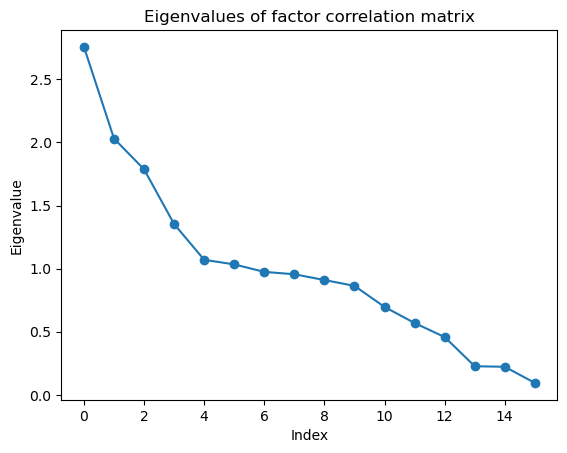

{'factors_used': 16,
 'Min Eigenvalue': np.float64(0.09477346266244606),
 'Max Eigenvalue': np.float64(2.7560361655084686),
 'Condition Number': 29.08025187730686,
 'Effective Rank': 12.714771935866207}

In [20]:
analytics.plot_eigenspectrum(C=C)

## Cluster Factors

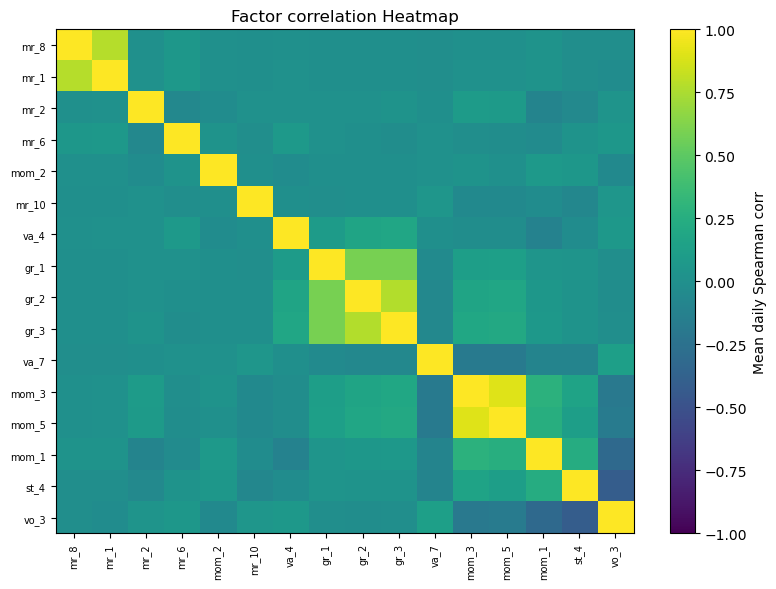

In [21]:
analytics.plot_heatmap(C)

## 4.2.2 Returns Regression: Fama-Macbeth

In [22]:
# Use z-scored exposures for regression
# Build clipped + z-scored panel from current panels

alpha_clip_z = {}
for f, x in panels["alpha_aligned"].items():
    xw = analytics._winsorize_by_row(x)
    xz = analytics._zscore_by_row(xw)
    alpha_clip_z[f] = xz

panel_clip_z = pd.concat(
    {f: alpha_clip_z[f].stack(dropna=False) for f in selected_factors_dq},
    axis=1
)
panel_clip_z.index = panel_clip_z.index.set_names(["date", "asset"])
panel_clip_z.columns.name = "factor"
display(panel_clip_z.head())

/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/2524594395.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  {f: alpha_clip_z[f].stack(dropna=False) for f in selected_factors_dq},
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/2524594395.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  {f: alpha_clip_z[f].stack(dropna=False) for f in selected_factors_dq},
/var/folders/n7/k_8ylm196lz3lzb72_x8vz340000gn/T/ipykernel_15644/2524594395.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a fu

factor             gr_1      gr_2     mom_2  mr_10      mr_2  va_4      mr_8  \
date       asset                                                               
2008-01-29 000005   NaN       NaN       NaN    NaN       NaN   NaN       NaN   
           000006   NaN -1.576795  0.517013    NaN -1.082253   NaN  2.295209   
           000008   NaN       NaN       NaN    NaN       NaN   NaN       NaN   
           000009   NaN       NaN       NaN    NaN       NaN   NaN       NaN   
           000012   NaN       NaN       NaN    NaN       NaN   NaN       NaN   

factor                 mr_6      st_4      va_7      vo_3      mr_1     mom_1  \
date       asset                                                                
2008-01-29 000005       NaN       NaN       NaN       NaN       NaN       NaN   
           000006  1.916744  0.260678  1.681058  0.243223  1.534837 -1.837605   
           000008       NaN       NaN       NaN       NaN       NaN       NaN   
           000009       NaN       NaN       NaN       NaN       NaN       NaN   
           000012       NaN       NaN       NaN       NaN       NaN       NaN   

factor                mom_3     mom_5      gr_3  
date       asset                                 
2008-01-29 000005       NaN       NaN       NaN  
           000006 -0.612246 -0.763377 -1.447868  
           000008       NaN       NaN       NaN  
           000009       NaN       NaN       NaN  
           000012       NaN       NaN       NaN

In [23]:
# Use z-scored exposures for regression
# You already have X_z (date x (alpha,ticker)) and R_fwd_s (date x ticker) and sample_mask (date x ticker)
# Ensure these correspond to the same DATE_MASK window already applied.
X_use = pd.concat(alpha_clip_z, axis=1)
X_use.columns = X_use.columns.set_names(["factor", "asset"])
X_use = X_use.sort_index(axis=1)
R_use = R_fwd.copy()
M_use = sample_mask.unstack("asset").reindex(index=R_use.index, columns=R_use.columns).fillna(False).astype(bool)

# --- utilities

B, fm_stats = analytics.fama_macbeth_factor_returns(
    X_panel=X_use,
    R_fwd=R_use,
    sample_mask=M_use,
    factors=filtered_factors,
    alpha_panel='factor',
    add_intercept=True,
    min_nobs=30,
    fill_missing_exposure_with_zero=True,
)

print("Factor returns panel B shape:", B.shape)
display(fm_stats.describe())

# Factor-return correlation (time-series corr)
corr_beta = B.corr()
display(corr_beta)

Factor returns panel B shape: (4390, 16)


,nobs,r2,intercept
count,4390.000000,4390.000000,4390.000000
mean,478.380410,0.100215,0.000210
std,20.947083,0.062063,0.018615
min,268.000000,0.009365,-0.099326
25%,467.000000,0.057365,-0.007256
50%,483.000000,0.084986,0.001103
75%,496.000000,0.126206,0.009540
max,500.000000,0.746782,0.105844


,gr_1,gr_2,mom_2,mr_10,mr_2,va_4,mr_8,mr_6,st_4,va_7,vo_3,mr_1,mom_1,mom_3,mom_5,gr_3
gr_1,1.000000,-0.243698,-0.005290,0.030575,-0.043836,0.034401,-0.037479,-0.039448,-0.038911,0.021729,0.021902,0.005034,0.017289,-0.044116,0.051900,-0.294177
gr_2,-0.243698,1.000000,0.020309,0.046215,-0.003421,-0.074692,-0.018286,0.003916,-0.037453,0.066011,0.021292,-0.036498,-0.006451,0.005911,-0.033398,-0.604086
mom_2,-0.005290,0.020309,1.000000,0.001580,-0.150550,-0.068427,-0.012005,-0.080692,0.116365,-0.037440,-0.111339,-0.059137,0.209304,-0.063636,0.021679,-0.003595
mr_10,0.030575,0.046215,0.001580,1.000000,-0.011203,-0.026381,-0.036407,0.036105,-0.087516,0.089556,0.098829,0.005006,0.025097,0.016336,-0.000822,-0.006614
mr_2,-0.043836,-0.003421,-0.150550,-0.011203,1.000000,0.022250,0.022735,0.044945,0.005606,-0.009582,0.005460,-0.008257,-0.060980,0.050489,-0.024473,0.027805
va_4,0.034401,-0.074692,-0.068427,-0.026381,0.022250,1.000000,-0.020869,-0.044753,-0.031443,0.030609,0.018030,0.032155,-0.012516,0.009812,0.004854,-0.050404
mr_8,-0.037479,-0.018286,-0.012005,-0.036407,0.022735,-0.020869,1.000000,-0.011118,0.059783,-0.017199,-0.034402,-0.504955,-0.039261,0.015012,-0.015533,0.027346
mr_6,-0.039448,0.003916,-0.080692,0.036105,0.044945,-0.044753,-0.011118,1.000000,-0.139179,-0.014526,0.104977,0.021840,0.040970,0.044547,-0.040212,-0.031500
st_4,-0.038911,-0.037453,0.116365,-0.087516,0.005606,-0.031443,0.059783,-0.139179,1.000000,-0.177668,-0.169819,0.059638,0.048326,0.015788,-0.038919,0.007863
va_7,0.021729,0.066011,-0.037440,0.089556,-0.009582,0.030609,-0.017199,-0.014526,-0.177668,1.000000,0.176854,-0.017981,0.050688,-0.031924,0.066093,0.070476


In [24]:
analytics.top_corr_pairs(corr_beta,N)

,alpha_i,alpha_j,mean_spearman,N_days
0,mom_3,mom_5,-0.892858,4391
1,gr_2,gr_3,-0.604086,4391
2,mr_8,mr_1,-0.504955,4383


#factors used: 16
min eig: 0.099716  max eig: 1.96622
condition number: 19.72
effective rank: 13.89


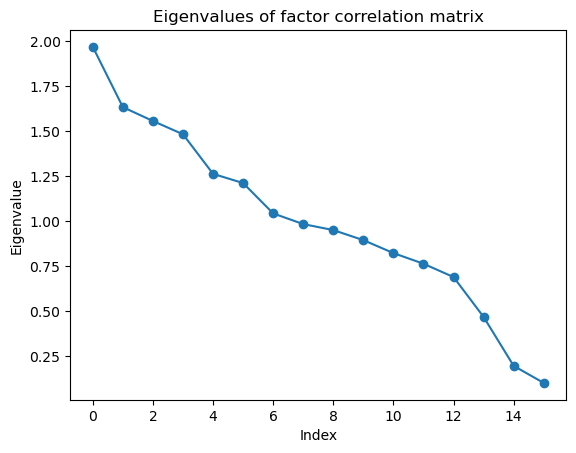

{'factors_used': 16,
 'Min Eigenvalue': np.float64(0.09971604311626851),
 'Max Eigenvalue': np.float64(1.9662197241047554),
 'Condition Number': 19.718188394340427,
 'Effective Rank': 13.89152137752647}

In [25]:
analytics.plot_eigenspectrum(corr_beta)

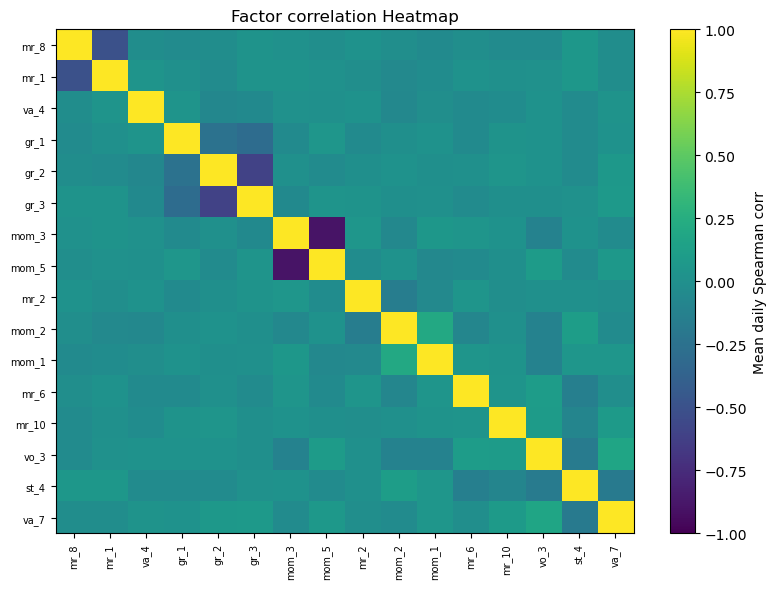

In [26]:
analytics.plot_heatmap(corr_beta)

# 4.3 Returns/IC Analysis

## 4.3.1 Newey_West t-stats

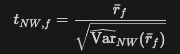

In [27]:
# Newey–West t-stats
# Whether each factor’s average return is statistically different from zero after correcting for time-series dependence/noise
L_NW = 5
nw_t = B.apply(lambda s: analytics.newey_west_tstat(s, L=L_NW), axis=0)
print("NW t-stats:")
display(nw_t.sort_values(ascending=False))

NW t-stats:


mr_8     12.547952
vo_3      4.877834
mom_2     3.930768
mr_2      2.638670
mom_3     2.546056
mr_6      2.519977
gr_2      2.416583
gr_1      1.369168
mr_10     0.596401
va_4      0.344483
gr_3     -1.006077
va_7     -1.917348
mom_5    -3.743135
mom_1    -4.282659
mr_1     -4.759885
st_4     -7.185105
dtype: float64

## 4.3.2 IC Horizon Decay & Persistence

In [28]:
# 1) Universe of factors to analyze
factor_universe = filtered_factors

# 2) Build long table from ic_summary dict
rows = []
for f in factor_universe:
    df = ic_summary[f].copy()
    df = df.reset_index().rename(columns={"index": "period"})
    df["period"] = pd.to_numeric(df["period"], errors="coerce")
    df["factor"] = f
    rows.append(df[["factor", "period", "n", "mean", "ICIR", "tstat"]])

ic_long = pd.concat(rows, ignore_index=True).dropna(subset=["period"]).sort_values(["factor", "period"])
ic_long["period"] = ic_long["period"].astype(int)

display(ic_long.head(10))
print("Factors:", ic_long["factor"].nunique(), "| Periods:", sorted(ic_long["period"].unique()))


,factor,period,n,mean,ICIR,tstat
0,gr_1,1,3897,0.000691,0.211144,0.830317
1,gr_1,5,3893,0.001359,0.420354,1.652179
2,gr_1,10,3888,0.002634,0.801981,3.150119
3,gr_1,20,3878,0.001716,0.526856,2.066786
4,gr_2,1,4391,0.001537,0.471480,1.968087
5,gr_2,5,4387,0.001457,0.426536,1.779669
6,gr_2,10,4382,0.001777,0.511737,2.133943
7,gr_2,20,4372,-0.001447,-0.402343,-1.675854
60,gr_3,1,4391,0.005299,1.324159,5.527407
61,gr_3,5,4387,0.006726,1.506324,6.284953


Factors: 16 | Periods: [np.int64(1), np.int64(5), np.int64(10), np.int64(20)]


In [ ]:
# 3) Wide tables + persistence metrics (p1=1,pmax=20 here)
ic_mean_w = ic_long.pivot(index="factor", columns="period", values="mean").sort_index(axis=1)
icir_w    = ic_long.pivot(index="factor", columns="period", values="ICIR").sort_index(axis=1)

p_min, p_max = icir_w.columns.min(), icir_w.columns.max()

summary = pd.DataFrame(index=icir_w.index)
summary["ICIR_p1"] = icir_w[p_min]
summary["ICIR_pmax"] = icir_w[p_max]
summary["ICIR_decay_ratio"] = summary["ICIR_pmax"] / summary["ICIR_p1"].replace(0, np.nan)
summary["ICIR_mean_across_horizons"] = icir_w.mean(axis=1)
summary["same_sign_all_horizons"] = np.sign(icir_w).replace(0, np.nan).nunique(axis=1).eq(1)
summary["meanIC_same_sign_all_horizons"] = np.sign(ic_mean_w).replace(0, np.nan).nunique(axis=1).eq(1)

# "Persistent" = high average ICIR and stable sign across horizons
summary["persistence_score"] = summary["ICIR_mean_across_horizons"] * summary["same_sign_all_horizons"].astype(int)

display(summary.sort_values("persistence_score", ascending=False))


,ICIR_p1,ICIR_pmax,ICIR_decay_ratio,ICIR_mean_across_horizons,same_sign_all_horizons,meanIC_same_sign_all_horizons,persistence_score
factor,,,,,,,
vo_3,5.982094,11.091100,1.854050,8.869411,True,True,8.869411
mr_8,5.424617,3.037082,0.559870,4.313042,True,True,4.313042
mr_1,3.345568,1.621295,0.484610,2.690588,True,True,2.690588
mr_10,1.305786,3.456755,2.647260,2.435346,True,True,2.435346
va_7,1.303236,2.843054,2.181535,2.266960,True,True,2.266960
mr_6,2.049943,2.353128,1.147899,2.203376,True,True,2.203376
mr_2,1.022895,3.227746,3.155502,2.042172,True,True,2.042172
gr_3,1.324159,0.831154,0.627685,1.248654,True,True,1.248654
mom_2,0.413009,1.192508,2.887364,0.654281,True,True,0.654281


In [36]:
# Inversion candidates from 4.3.2 + NW t-stats
cand = summary.copy()
cand["nw_t"] = nw_t.reindex(cand.index)

invert_candidates = cand[
    (cand["ICIR_mean_across_horizons"] < 0) &
    (cand["same_sign_all_horizons"]) &
    (cand["nw_t"] < -2)
].sort_values("ICIR_mean_across_horizons")

display(invert_candidates[[
    "ICIR_p1","ICIR_pmax","ICIR_mean_across_horizons",
    "same_sign_all_horizons","nw_t"
]])

,ICIR_p1,ICIR_pmax,ICIR_mean_across_horizons,same_sign_all_horizons,nw_t
factor,,,,,
st_4,-5.348713,-7.473282,-6.580728,True,-7.185105
mom_1,-1.464987,-3.439469,-2.528368,True,-4.282659
mom_5,-0.691705,-2.727850,-1.580923,True,-3.743135


In [37]:
# factor_sign: +1 keep, -1 invert
factor_sign = pd.Series(1.0, index=summary.index)
factor_sign.loc[invert_candidates.index] = -1.0
display(factor_sign.sort_values())


factor
mom_1   -1.0
mom_5   -1.0
st_4    -1.0
gr_1     1.0
gr_2     1.0
gr_3     1.0
mom_2    1.0
mom_3    1.0
mr_1     1.0
mr_10    1.0
mr_2     1.0
mr_6     1.0
mr_8     1.0
va_4     1.0
va_7     1.0
vo_3     1.0
dtype: float64

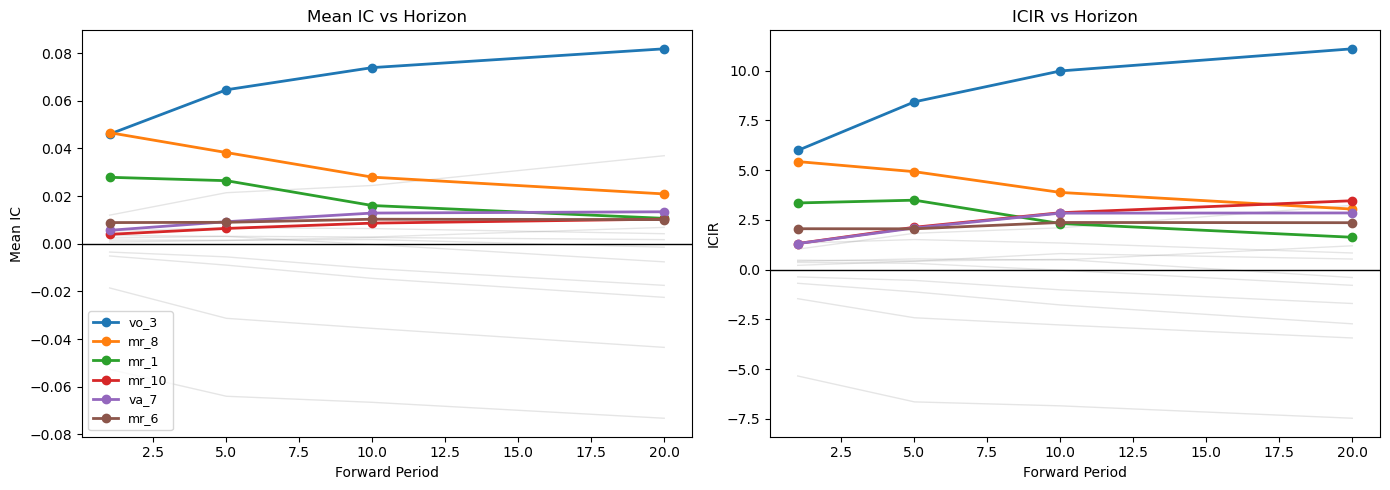

In [30]:
# 4) Plot horizon decay: all factors + top persistent highlights
top_k = 6
top_factors = summary.sort_values("persistence_score", ascending=False).head(top_k).index.tolist()
periods = sorted(icir_w.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean IC decay
for f in ic_mean_w.index:
    axes[0].plot(periods, ic_mean_w.loc[f, periods], color="grey", alpha=0.2, linewidth=1)
for f in top_factors:
    axes[0].plot(periods, ic_mean_w.loc[f, periods], marker="o", linewidth=2, label=f)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Mean IC vs Horizon")
axes[0].set_xlabel("Forward Period")
axes[0].set_ylabel("Mean IC")
axes[0].legend(loc="best", fontsize=9)

# ICIR decay
for f in icir_w.index:
    axes[1].plot(periods, icir_w.loc[f, periods], color="grey", alpha=0.2, linewidth=1)
for f in top_factors:
    axes[1].plot(periods, icir_w.loc[f, periods], marker="o", linewidth=2, label=f)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("ICIR vs Horizon")
axes[1].set_xlabel("Forward Period")
axes[1].set_ylabel("ICIR")

plt.tight_layout()
plt.show()

## 4.3.3 IC Robustness

In [33]:
## 4.3.3 IC Robustness (Distribution-Aware)
period_focus = 1   # change to 5/10/20

rows = []
for f in factor_universe:
    df = ic_summary[f]
    if period_focus not in df.index:
        continue
    r = df.loc[period_focus]
    rows.append({
        "factor": f,
        "n": r.get("n"),
        "mean_ic": r.get("mean"),
        "icir": r.get("ICIR"),
        "tstat": r.get("tstat"),
        "skew": r.get("skew"),
        "kurt": r.get("kurt"),
        "p05": r.get("p05"),
        "p50": r.get("p50"),
        "p95": r.get("p95"),
    })

rob = pd.DataFrame(rows).set_index("factor")

# Tail/asymmetry diagnostics
rob["tail_span"] = rob["p95"] - rob["p05"]            # smaller = less dispersion
rob["left_tail_penalty"] = (rob["p50"] - rob["p05"])  # larger = worse downside tail

# Simple robustness score (z-scored components)
# higher icir/tstat is good; lower |skew|/kurt/left-tail is good
def z(s): 
    return (s - s.mean()) / (s.std(ddof=0) + 1e-12)

rob["robustness_score"] = (
    + z(rob["icir"])
    + 0.5 * z(rob["tstat"])
    - 0.5 * z(rob["left_tail_penalty"])
    - 0.3 * z(rob["kurt"].clip(lower=-5, upper=20))
    - 0.2 * z(rob["skew"].abs())
)

display(rob.sort_values("robustness_score", ascending=False))

,n,mean_ic,icir,tstat,skew,kurt,p05,p50,p95,tail_span,left_tail_penalty,robustness_score
factor,,,,,,,,,,,,
vo_3,4633.0,0.046020,5.982094,25.649806,-0.108119,0.380159,-0.157993,0.049096,0.241869,0.399862,0.207089,2.643399
mr_8,4652.0,0.046636,5.424617,23.307121,-0.030359,0.935450,-0.179887,0.048184,0.257482,0.437369,0.228070,2.176100
mr_6,4443.0,0.008880,2.049943,8.607552,0.071589,0.175459,-0.100769,0.006456,0.126892,0.227661,0.107225,1.205350
mr_10,3087.0,0.003955,1.305786,4.570251,-0.066953,-0.145565,-0.074854,0.004842,0.079961,0.154815,0.079695,1.109088
gr_3,4391.0,0.005299,1.324159,5.527407,0.022881,0.105924,-0.097090,0.003805,0.112130,0.209220,0.100895,1.061039
gr_2,4391.0,0.001537,0.471480,1.968087,-0.009877,-0.399264,-0.083099,0.001662,0.085127,0.168226,0.084761,1.019690
mr_1,4631.0,0.027895,3.345568,14.341911,-0.096491,0.561554,-0.190065,0.029283,0.240277,0.430342,0.219347,0.956169
va_7,4401.0,0.005639,1.303236,5.446260,0.044601,0.322632,-0.108222,0.004920,0.117952,0.226174,0.113142,0.754511
gr_1,3897.0,0.000691,0.211144,0.830317,-0.035444,-0.340525,-0.085109,0.000285,0.085882,0.170991,0.085394,0.720995


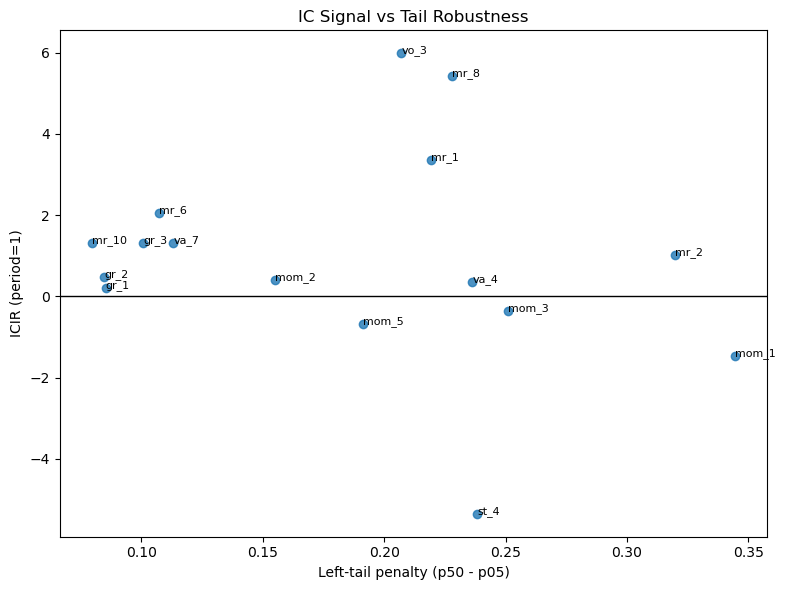

In [35]:
 # Quick visual: ICIR vs downside-tail penalty
plt.figure(figsize=(8, 6))
x = rob["left_tail_penalty"]
y = rob["icir"]

plt.scatter(x, y, alpha=0.8)
for f in rob.index:
    plt.text(x.loc[f], y.loc[f], f, fontsize=8)

plt.axhline(0, color="black", lw=1)
plt.xlabel("Left-tail penalty (p50 - p05)")
plt.ylabel(f"ICIR (period={period_focus})")
plt.title("IC Signal vs Tail Robustness")
plt.tight_layout()
plt.show()


## 4.3.4 Factor Selection

In [39]:
C_use = C_spear.copy()
factors = filtered_factors

# signed quality score: prefer stable positive ICIR; if inverted, flip ICIR contribution
rank_df = pd.DataFrame(index=factors)
rank_df["sign"] = factor_sign.reindex(factors).fillna(1.0)
rank_df["icir_mean"] = summary.reindex(factors)["ICIR_mean_across_horizons"]
rank_df["robustness"] = rob.reindex(factors)["robustness_score"]
rank_df["signed_icir_mean"] = rank_df["icir_mean"] * rank_df["sign"]
rank_df["select_score"] = rank_df["signed_icir_mean"] + 0.35 * rank_df["robustness"]

display(rank_df.sort_values("select_score", ascending=False))

,sign,icir_mean,robustness,signed_icir_mean,select_score
vo_3,1.0,8.869411,2.643399,8.869411,9.794601
mr_8,1.0,4.313042,2.176100,4.313042,5.074677
st_4,-1.0,-6.580728,-4.534120,6.580728,4.993786
mr_1,1.0,2.690588,0.956169,2.690588,3.025247
mr_10,1.0,2.435346,1.109088,2.435346,2.823527
mr_6,1.0,2.203376,1.205350,2.203376,2.625249
va_7,1.0,2.266960,0.754511,2.266960,2.531039
mom_1,-1.0,-2.528368,-2.102797,2.528368,1.792389
gr_3,1.0,1.248654,1.061039,1.248654,1.620017
mr_2,1.0,2.042172,-1.467251,2.042172,1.528634


In [42]:
# Keep highest-score factor first, then drop factors with |corr| >= threshold to selected names.

corr_threshold = 0.50
selected = []
dropped = {}

ordered = rank_df.sort_values("select_score", ascending=False).index.tolist()

for f in ordered:
    if not selected:
        selected.append(f)
        continue
    max_abs_corr = np.max(np.abs(C_use.loc[f, selected].values))
    if max_abs_corr < corr_threshold:
        selected.append(f)
    else:
        dropped[f] = {"reason": f"|corr|>={corr_threshold}", "max_abs_corr_to_selected": float(max_abs_corr)}

selected_signed = pd.DataFrame({
    "factor": selected,
    "sign": factor_sign.reindex(selected).values,
    "select_score": rank_df.reindex(selected)["select_score"].values
}).sort_values("select_score", ascending=False)

display(selected_signed)
print("Selected:", len(selected), "/", len(factors))
display(pd.DataFrame(dropped).T)

,factor,sign,select_score
0,vo_3,1.0,9.794601
1,mr_8,1.0,5.074677
2,st_4,-1.0,4.993786
3,mr_10,1.0,2.823527
4,mr_6,1.0,2.625249
5,va_7,1.0,2.531039
6,mom_1,-1.0,1.792389
7,gr_3,1.0,1.620017
8,mr_2,1.0,1.528634
9,mom_5,-1.0,1.255862


Selected: 12 / 16


,reason,max_abs_corr_to_selected
mr_1,|corr|>=0.5,0.777004
gr_1,|corr|>=0.5,0.586932
gr_2,|corr|>=0.5,0.771999
mom_3,|corr|>=0.5,0.903324


In [ ]:
# Final transformed factor name
# Convention: prefix "inv_" for inverted factors
final_factor_map = {f: (f"inv_{f}" if factor_sign.get(f, 1.0) < 0 else f) for f in selected}
final_factor_map

{'vo_3': 'vo_3',
 'mr_8': 'mr_8',
 'st_4': 'inv_st_4',
 'mr_10': 'mr_10',
 'mr_6': 'mr_6',
 'va_7': 'va_7',
 'mom_1': 'inv_mom_1',
 'gr_3': 'gr_3',
 'mr_2': 'mr_2',
 'mom_5': 'inv_mom_5',
 'mom_2': 'mom_2',
 'va_4': 'va_4'}

## 4.3.5 Refined Signed Pool: FM + NW Validation


In [45]:
selected_refined = list(selected)
sign_refined = factor_sign.reindex(selected_refined).fillna(1.0)

# 1) Build signed exposures
alpha_signed = {
    f: panels["alpha_aligned"][f] * sign_refined[f]
    for f in selected_refined
}
alpha_rank_signed = {
    f: panels["alpha_rank"][f] * sign_refined[f]
    for f in selected_refined
}

print("Selected refined factors:", len(selected_refined))

Selected refined factors: 12


In [46]:
# 2) Build clipped + zscored panel for FM regression
alpha_clip_z_refined = {}
for f, x in alpha_signed.items():
    xw = analytics._winsorize_by_row(x)
    xz = analytics._zscore_by_row(xw)
    alpha_clip_z_refined[f] = xz

X_refined = pd.concat(alpha_clip_z_refined, axis=1)
X_refined.columns = X_refined.columns.set_names(["factor", "asset"])
X_refined = X_refined.sort_index(axis=1)

R_use = R_fwd.copy()
M_use = (
    sample_mask.unstack("asset")
    .reindex(index=R_use.index, columns=R_use.columns)
    .fillna(False).astype(bool)
)

B_refined, fm_stats_refined = analytics.fama_macbeth_factor_returns(
    X_panel=X_refined,
    R_fwd=R_use,
    sample_mask=M_use,
    factors=selected_refined,
    alpha_panel="factor",
    add_intercept=True,
    min_nobs=30,
    fill_missing_exposure_with_zero=True,
)

print("B_refined shape:", B_refined.shape)
display(fm_stats_refined.describe())

B_refined shape: (4390, 12)


,nobs,r2,intercept
count,4390.000000,4390.000000,4390.000000
mean,478.380410,0.084936,0.000212
std,20.947083,0.058581,0.018617
min,268.000000,0.004030,-0.099323
25%,467.000000,0.044899,-0.007254
50%,483.000000,0.070145,0.001087
75%,496.000000,0.109174,0.009539
max,500.000000,0.701479,0.105862


In [49]:
# 3) NW t-stats + comparison vs previous full-pool NW t
L_NW = 5
nw_t_refined = B_refined.apply(lambda s: analytics.newey_west_tstat(s, L=L_NW), axis=0).sort_values(ascending=False)

print("Refined NW t-stats:")
display(nw_t_refined)

Refined NW t-stats:


mr_8     11.291203
st_4      7.492796
vo_3      5.516965
mom_2     4.144538
mom_1     4.034715
mr_6      2.913594
mr_2      2.901294
gr_3      2.028899
mom_5     1.919321
mr_10     0.427221
va_4      0.369008
va_7     -1.737243
dtype: float64

,alpha_i,alpha_j,mean_spearman,N_days


#factors used: 12
min eig: 0.649229  max eig: 1.62093
condition number: 2.50
effective rank: 11.56


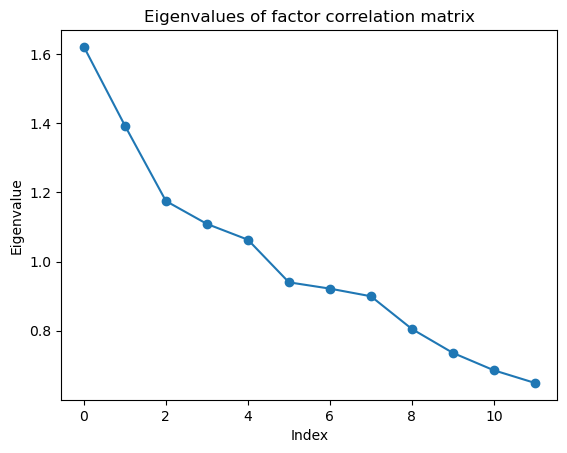

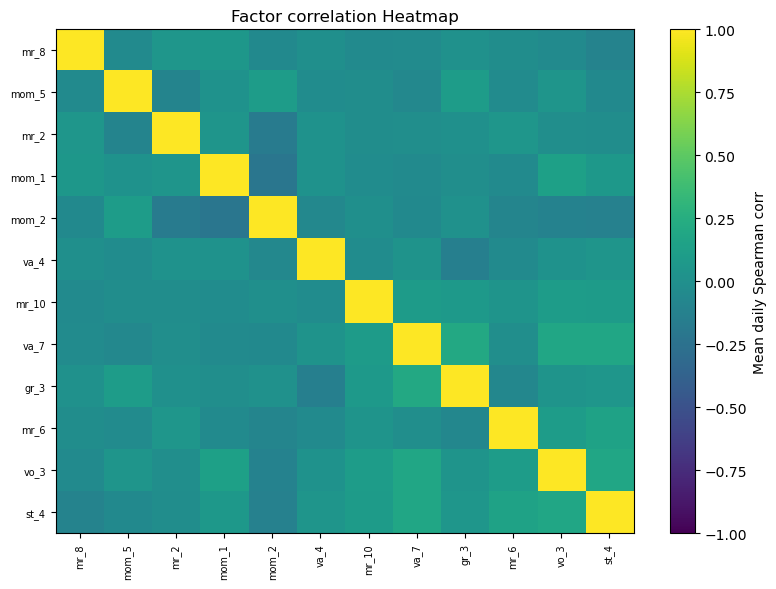

In [48]:
# 4) Residual collinearity diagnostics on refined signed pool
corr_beta_refined = B_refined.corr()

display(analytics.top_corr_pairs(corr_beta_refined, corr_beta_refined.notna().astype(int)*B_refined.shape[0], min_abs_corr=0.3, min_days=1, topk=20))
analytics.plot_eigenspectrum(corr_beta_refined)
analytics.plot_heatmap(corr_beta_refined)

In [53]:
out_dir = Path("data/cache/final_factors")
out_dir.mkdir(parents=True, exist_ok=True)

# final_factors: list[str]
# factor_sign: pd.Series (+1/-1)
# nw_t_refined: pd.Series
# alpha_signed: dict[factor] -> DataFrame(date x asset)

meta = pd.DataFrame({
    "factor": selected_refined,
    "sign": factor_sign.reindex(selected_refined).values,
    "nw_t": nw_t_refined.reindex(selected_refined).values,
}).set_index("factor")
meta.to_parquet(out_dir / "final_factor_meta.parquet")

# one panel, easy to load: index=date, columns=(factor, asset)
X_final = pd.concat({f: alpha_signed[f] for f in selected_refined}, axis=1)
X_final.columns = X_final.columns.set_names(["factor", "asset"])
X_final.to_parquet(out_dir / "final_factor_panel.parquet")